# Uncontracted basis sets

Up to this point, we have previously defined a `BasisSet` class, which created a struct that retained all information of the basis. However, there are three issues with that definition. First, it defines all basis as CGTOs, and primitives as a single component CGTO, leading to a whole set of operations that would be mitypliying by one being evaluated. Second, in the relativistic context, it is common to work with uncontracted basis sets, which by itself justifies the use of an uncontracted basis set. Finally, the `BasisSet` class intends to use legacy code, without intermediates, which is way less efficient. 

Therefore, we will build an updated `UncontractedBasisSet`, and wrappers over the shell-based implementation of matrix element evaluation. 

In [1]:
from typing import List
from dataclasses import dataclass

import numpy as np
from numpy.typing import NDArray

from pyscf import gto

from py_mods.src.integrals.GTO import (
    GTO,
    create_normalized_GTO,
    S_ab_shell,
    T_ab_shell,
    g_abcd_shell,
)
from py_mods.src.integrals.internal.coulomb_utils import V_ab_Z_shell
from py_mods.src.SCF.plot_utilities import plot_map

The structs we define for the basis and the atoms are:

In [2]:
@dataclass
class UncontractedBasisSet:
    GTO_list: List[GTO]
    n_GTOs: int
    l_dims: NDArray[np.int16]
    start_indices: NDArray[np.int16]
    end_indices: NDArray[np.int16]
    n_mat_elem: int


@dataclass
class AtomSet:
    r_atoms: NDArray[np.float64]
    q_atoms: NDArray[np.float64]
    n_atoms: int

And the functions we will use to construct it are:

In [3]:
def create_UncontractedBasisSet(GTO_list: List[GTO]) -> UncontractedBasisSet:

    n_gtos = len(GTO_list)
    l_dims = np.array([len(gto.l_projections) for gto in GTO_list], dtype=np.int16)
    start_indices = np.zeros_like(l_dims, dtype=np.int16)
    end_indices = np.zeros_like(l_dims, dtype=np.int16)
    for i in range(n_gtos):
        start_indices[i] = sum(l_dims[:i])
        end_indices[i] = start_indices[i] + l_dims[i]

    n_mat_elem = int(np.sum(l_dims))

    return UncontractedBasisSet(
        GTO_list=GTO_list,
        n_GTOs=n_gtos,
        l_dims=l_dims,
        start_indices=start_indices,
        end_indices=end_indices,
        n_mat_elem=n_mat_elem,
    )

Lets generate a UBS:

In [21]:
l = 0

r1 = np.array([0.0, 0.0, 0.0])
r2 = np.array([0.0, 0.0, 1.4])

exp = 0.3

atom_pos = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 1.4]])
atom_charges = np.array([1.0, 1.0])

H_1s_1 = create_normalized_GTO(r1, exp, l)
H_1p_1 = create_normalized_GTO(r1, exp, l + 1)
H_1d_1 = create_normalized_GTO(r1, exp, l + 2)
H_1s_2 = create_normalized_GTO(r2, exp, l)
H_1p_2 = create_normalized_GTO(r2, exp, l + 1)
H_1d_2 = create_normalized_GTO(r2, exp, l + 2)

GTO_list = [H_1s_1, H_1p_1, H_1s_2, H_1p_2]

UBS = create_UncontractedBasisSet(GTO_list)

print(repr(UBS))

UncontractedBasisSet(GTO_list=[GTO(R=array([0., 0., 0.]), exp=0.3, total_L=0, l_projections=array([[0, 0, 0]], dtype=int32), l_dim=1, normalization_constants=array([0.28890232]), charge=1), GTO(R=array([0., 0., 0.]), exp=0.3, total_L=1, l_projections=array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]], dtype=int32), l_dim=3, normalization_constants=array([0.31647664, 0.31647664, 0.31647664]), charge=1), GTO(R=array([0. , 0. , 1.4]), exp=0.3, total_L=0, l_projections=array([[0, 0, 0]], dtype=int32), l_dim=1, normalization_constants=array([0.28890232]), charge=1), GTO(R=array([0. , 0. , 1.4]), exp=0.3, total_L=1, l_projections=array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]], dtype=int32), l_dim=3, normalization_constants=array([0.31647664, 0.31647664, 0.31647664]), charge=1)], n_GTOs=4, l_dims=array([1, 3, 1, 3], dtype=int16), start_indices=array([0, 1, 4, 5], dtype=int16), end_indices=array([1, 4, 5, 8], dtype=int16), n_mat_elem=8)



---

## S UBS evaluation
We start computing some $S$ matrix elements. This is done simply computing each block and placing it in the correct place. Symmetry can be enforced by just computing a triangle, and then either assume symmetry or not:

In [ ]:
def S_UncontractedBasisSet(UBS: UncontractedBasisSet, symmetric: bool = True) -> NDArray[np.float64]:
    n_mat_elem = UBS.n_mat_elem
    
    S = np.zeros((n_mat_elem, n_mat_elem), dtype=np.float64)
    n_gtos = UBS.n_GTOs

    for i in range(n_gtos):
        for j in range(i, n_gtos):
            i0 = int(UBS.start_indices[i])
            i1 = int(UBS.end_indices[i])
            j0 = int(UBS.start_indices[j])
            j1 = int(UBS.end_indices[j])

            S_block = S_ab_shell(UBS.GTO_list[i], UBS.GTO_list[j])
            S[i0:i1, j0:j1] = S_block
    
    if not symmetric:
        for i in range(n_gtos):
            for j in range(i):  # j < i
                i0 = int(UBS.start_indices[i])
                i1 = int(UBS.end_indices[i])
                j0 = int(UBS.start_indices[j])
                j1 = int(UBS.end_indices[j])
                
                S_block = S_ab_shell(UBS.GTO_list[i], UBS.GTO_list[j])
                S[i0:i1, j0:j1] = S_block
                
    else:
        for i in range(n_mat_elem):
            for j in range(i + 1, n_mat_elem):
                S[j, i] = S[i, j]
            
    return S

In [6]:
S_UBS = S_UncontractedBasisSet(UBS)
S_UBS_nosymm = S_UncontractedBasisSet(UBS, symmetric=False)
print(np.allclose(S_UBS, S_UBS_nosymm))

True


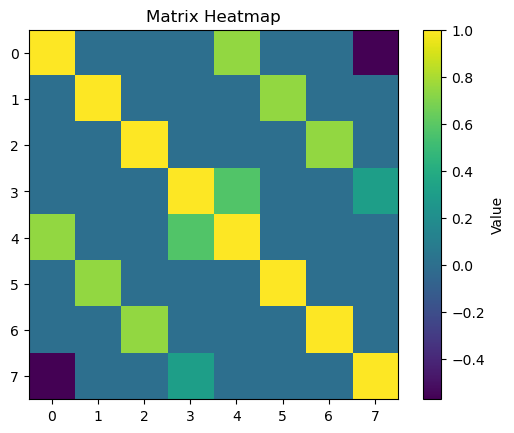

In [7]:
plot_map(S_UBS)


---

## T UBS evaluation

Now for T:

In [8]:
def T_UncontractedBasisSet(
    UBS: UncontractedBasisSet, symmetric: bool = True
) -> NDArray[np.float64]:
    n_mat_elem = UBS.n_mat_elem

    T = np.zeros((n_mat_elem, n_mat_elem), dtype=np.float64)
    n_gtos = UBS.n_GTOs

    for i in range(n_gtos):
        for j in range(i, n_gtos):
            i0 = int(UBS.start_indices[i])
            i1 = int(UBS.end_indices[i])
            j0 = int(UBS.start_indices[j])
            j1 = int(UBS.end_indices[j])

            T_block = T_ab_shell(UBS.GTO_list[i], UBS.GTO_list[j])
            T[i0:i1, j0:j1] = T_block

    if not symmetric:
        for i in range(n_gtos):
            for j in range(i):  # j < i
                i0 = int(UBS.start_indices[i])
                i1 = int(UBS.end_indices[i])
                j0 = int(UBS.start_indices[j])
                j1 = int(UBS.end_indices[j])

                T_block = T_ab_shell(UBS.GTO_list[i], UBS.GTO_list[j])
                T[i0:i1, j0:j1] = T_block

    else:
        for i in range(n_mat_elem):
            for j in range(i + 1, n_mat_elem):
                T[j, i] = T[i, j]

    return T

In [9]:
T_UBS = T_UncontractedBasisSet(UBS)
T_UBS_nosymm = T_UncontractedBasisSet(UBS, symmetric=False)
print(np.allclose(T_UBS, T_UBS_nosymm))

True


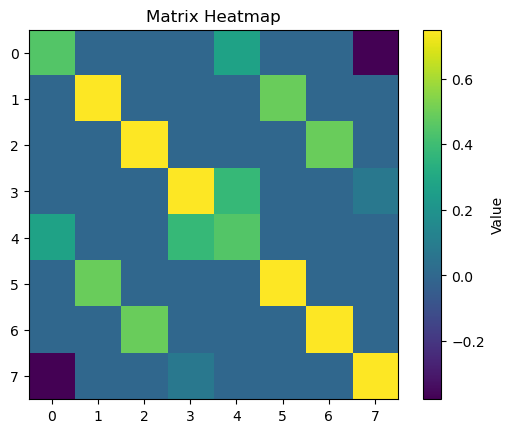

In [10]:
plot_map(T_UBS)


---

## V UBS evaluation

Now for the nuclear attraction:
1. We need to define the atom list
2. Wrap around V_ab_Z_shell

In [11]:
def create_AtomSet(atom_positions, atom_charges) -> AtomSet:
    r_atoms = np.array(atom_positions, dtype=np.float64)
    q_atoms = np.array(atom_charges, dtype=np.float64)
    n_atoms = len(q_atoms)
    return AtomSet(r_atoms=r_atoms, q_atoms=q_atoms, n_atoms=n_atoms)

In [12]:
def V_UncontractedBasisSet(
    UBS: UncontractedBasisSet, atom_set: AtomSet, symmetric: bool = True
) -> NDArray[np.float64]:
    n_mat_elem = UBS.n_mat_elem
    n_atoms = atom_set.n_atoms

    V = np.zeros((n_mat_elem, n_mat_elem), dtype=np.float64)
    n_gtos = UBS.n_GTOs

    for i in range(n_gtos):
        for j in range(i, n_gtos):
            i0 = int(UBS.start_indices[i])
            i1 = int(UBS.end_indices[i])
            j0 = int(UBS.start_indices[j])
            j1 = int(UBS.end_indices[j])

            for iatom in range(n_atoms):
                V_block = V_ab_Z_shell(
                    UBS.GTO_list[i],
                    UBS.GTO_list[j],
                    atom_set.q_atoms[iatom],
                    atom_set.r_atoms[iatom],
                )

                V[i0:i1, j0:j1] += V_block

    if not symmetric:
        for i in range(n_gtos):
            for j in range(i):  # j < i
                i0 = int(UBS.start_indices[i])
                i1 = int(UBS.end_indices[i])
                j0 = int(UBS.start_indices[j])
                j1 = int(UBS.end_indices[j])

                for iatom in range(n_atoms):
                    V_block = V_ab_Z_shell(
                        UBS.GTO_list[i],
                        UBS.GTO_list[j],
                        atom_set.q_atoms[iatom],
                        atom_set.r_atoms[iatom],
                    )
                    V[i0:i1, j0:j1] += V_block

    else:
        for i in range(n_mat_elem):
            for j in range(i + 1, n_mat_elem):
                V[j, i] = V[i, j]

    return V

In [13]:
%%timeit
V_UBS = V_UncontractedBasisSet(UBS, create_AtomSet(atom_pos, atom_charges))

3.3 ms ± 15.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [14]:
%%timeit
V_UBS_nosymm = V_UncontractedBasisSet(
    UBS, create_AtomSet(atom_pos, atom_charges), symmetric=False
)

5.15 ms ± 25.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [15]:
atom_pos = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 1.4]])
atom_charges = np.array([1.0, 1.0])

V_UBS = V_UncontractedBasisSet(UBS, create_AtomSet(atom_pos, atom_charges))
V_UBS_nosymm = V_UncontractedBasisSet(
    UBS, create_AtomSet(atom_pos, atom_charges), symmetric=False
)

print(np.allclose(V_UBS, V_UBS_nosymm))

True


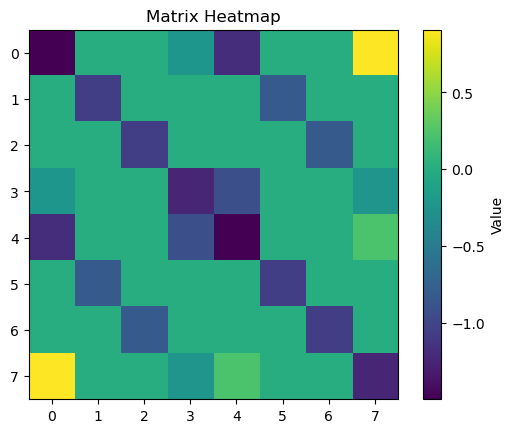

In [16]:
plot_map(V_UBS)


---

## ERI UBS evaluation

And finally ERIs:

In [17]:
def ERIs_Uncontracted(UBS):
    n = UBS.n_mat_elem
    ERI = np.zeros((n, n, n, n), dtype=np.float64)

    n_gtos = UBS.n_GTOs
    for i in range(n_gtos):
        i0, i1 = int(UBS.start_indices[i]), int(UBS.end_indices[i])
        for j in range(n_gtos):
            j0, j1 = int(UBS.start_indices[j]), int(UBS.end_indices[j])
            for k in range(n_gtos):
                k0, k1 = int(UBS.start_indices[k]), int(UBS.end_indices[k])
                for l in range(n_gtos):
                    l0, l1 = int(UBS.start_indices[l]), int(UBS.end_indices[l])

                    block = g_abcd_shell(
                        UBS.GTO_list[i],
                        UBS.GTO_list[j],
                        UBS.GTO_list[k],
                        UBS.GTO_list[l],
                    )

                    ERI[i0:i1, j0:j1, k0:k1, l0:l1] = block

    return ERI

In [18]:
ERI_UBS = ERIs_Uncontracted(UBS)

In [19]:
mol = gto.M(
    atom="H 0 0 0; H 0 0 1.4",
    unit="Bohr",
    basis={
        "H": gto.basis.parse(f"""
        H S
        0.3    1
        # 1    1
        H P 
        0.3    1
        """),
    },
    cart=True,
)

# Get overlap and kinetic energy matrices
mol.build()
print(mol.ao_labels())

S_pyscf = mol.intor("int1e_ovlp")
T_pyscf = mol.intor("int1e_kin")
V_pyscf = mol.intor("int1e_nuc")
ref_eri = mol.intor("int2e")

norm_vec = 1.0 / np.sqrt(np.diag(S_pyscf))

ref_eri *= norm_vec[:, None, None, None]
ref_eri *= norm_vec[None, :, None, None]
ref_eri *= norm_vec[None, None, :, None]
ref_eri *= norm_vec[None, None, None, :]

['0  H 1s    ', '0  H 2px   ', '0  H 2py   ', '0  H 2pz   ', '1  H 1s    ', '1  H 2px   ', '1  H 2py   ', '1  H 2pz   ']


In [20]:
print("Overlap max difference:", np.max(S_UBS - S_pyscf))
print("Kinetic max difference:", np.max(T_UBS - T_pyscf))
print("Nuclear attraction max difference:", np.max(V_UBS - V_pyscf))
print("ERI max difference:", np.max(ERI_UBS - ref_eri))

Overlap max difference: 1.1102230246251565e-16
Kinetic max difference: 1.3877787807814457e-16
Nuclear attraction max difference: 4.6074255521944e-15
ERI max difference: 2.7755575615628914e-15


Which is fantastic.